# ch190 — Project: Word Embedding Visualization

> **Prerequisites:** ch173 (SVD), ch174 (PCA Intuition), ch175 (Dimensionality Reduction), ch129 (Distance in Vector Space), ch143 (Angles Between Vectors), ch177 (Linear Algebra for Neural Networks)
> **Part:** VI — Linear Algebra
> **Difficulty:** Intermediate
> **Estimated time:** 60–80 minutes

## 0. Overview

### Problem Statement

Word embeddings map words to dense vectors in a high-dimensional space such that semantically related words are geometrically close. The most famous result: in Word2Vec embedding space, **king − man + woman ≈ queen**. This is not a coincidence — it reflects linear structure in the geometry of meaning.

This project builds word embeddings from scratch using SVD on a co-occurrence matrix:
1. Build a co-occurrence matrix from a structured toy corpus
2. Apply PPMI (Positive Pointwise Mutual Information) weighting
3. Factorize via SVD to get low-dimensional word vectors
4. Measure nearest-neighbor quality and category precision
5. Demonstrate word arithmetic and analogy completion
6. Visualize the geometry with PCA

### Concepts Used
- Co-occurrence matrices and PMI weighting
- SVD factorization of non-square matrices *(ch173)*
- PCA for 2D projection *(ch174, ch175)*
- Cosine similarity between vectors *(ch143)*
- Vector arithmetic in semantic space *(ch121–130)*
- Nearest-neighbor search *(ch129)*

## 1. Setup

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
plt.style.use('seaborn-v0_8-whitegrid')

# No external NLP libraries. Everything built from numpy.

WINDOW_SIZE = 3   # co-occurrence context window radius
MIN_FREQ    = 2   # minimum word frequency to include in vocabulary
K_EMBED     = 20  # SVD embedding dimension

print("Word Embedding Visualization")
print("Building embeddings from co-occurrence matrix via SVD")

Word Embedding Visualization
Building embeddings from co-occurrence matrix via SVD


In [2]:
# --- Structured Toy Corpus ---
# Carefully constructed so SVD recovers five semantic categories.
corpus = [
    # Royalty / gender
    "the king ruled the kingdom with authority",
    "the queen ruled the kingdom with grace",
    "the king and queen led the royal court",
    "the prince became king after the coronation",
    "the princess became queen at the ceremony",
    "the man served the king loyally",
    "the woman served the queen loyally",
    "the royal family lived in the palace",
    "the king is a powerful man",
    "the queen is a powerful woman",
    "the prince is a young man in the palace",
    "the princess is a young woman in the palace",
    # Animals
    "the dog barked at the cat",
    "the cat sat near the dog",
    "the dog ran fast across the field",
    "the cat chased the mouse in the garden",
    "dogs and cats are common pets",
    "the puppy played with the kitten",
    "the wolf howled and the fox ran away",
    "the lion is the king of the animals",
    # Food
    "pizza and pasta are popular food",
    "the chef cooked pasta with tomato sauce",
    "she ate pizza for dinner last night",
    "rice and bread are staple food items",
    "the bread was baked fresh in the oven",
    "sushi is made with rice and fish",
    "the soup was hot and the bread was fresh",
    # Technology
    "the computer processed the data quickly",
    "the software ran on the computer system",
    "data and algorithms power machine learning",
    "the network connected many computer systems",
    "code and data are the foundation of software",
    "machine learning uses algorithms and data",
    "the server processed network requests fast",
    # Sports
    "the player scored a goal in the match",
    "the team won the championship this season",
    "the coach trained the team every morning",
    "the athlete ran fast to win the race",
    "the match ended with a final score",
    "the player and the team celebrated the win",
]

CATEGORIES = {
    'royalty': (['king','queen','man','woman','prince','princess','royal','palace'], 'goldenrod'),
    'animals': (['dog','cat','wolf','lion','puppy','kitten'], 'forestgreen'),
    'food':    (['pizza','pasta','bread','rice','soup','food'], 'tomato'),
    'tech':    (['computer','software','data','algorithm','network','machine'], 'royalblue'),
    'sports':  (['player','team','coach','match','goal','score','athlete'], 'darkorchid'),
}

STOP_WORDS = {'the','a','an','and','is','are','of','in','at','to','with','was','for',
              'this','it','be','on','by','as','from','or','not','but','so','she','he'}

print(f"Corpus: {len(corpus)} sentences")

Corpus: 40 sentences


In [3]:
# --- Build Vocabulary and Co-occurrence Matrix ---

def tokenize(sentence):
    return [w.strip('.,!?;') for w in sentence.lower().split()]

# Count all word frequencies
all_tokens = [w for s in corpus for w in tokenize(s)]
word_counts = Counter(all_tokens)

# Build vocabulary: frequent, non-stopword tokens
vocab = sorted([w for w, c in word_counts.items()
                if c >= MIN_FREQ and w not in STOP_WORDS])
word_to_idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

# Build co-occurrence matrix (distance-weighted)
C = np.zeros((V, V), dtype=float)
for sentence in corpus:
    tokens = [w for w in tokenize(sentence) if w in word_to_idx]
    for pos, word in enumerate(tokens):
        i = word_to_idx[word]
        for offset in range(1, WINDOW_SIZE + 1):
            for direction in [-1, 1]:
                ctx_pos = pos + direction * offset
                if 0 <= ctx_pos < len(tokens):
                    j = word_to_idx[tokens[ctx_pos]]
                    C[i, j] += 1.0 / offset   # closer context = higher weight

print(f"Vocabulary: {V} words")
print(f"Co-occurrence matrix: {C.shape}")
print(f"Non-zero entries: {(C > 0).sum()} ({(C>0).sum()/(V*V)*100:.1f}% dense)")

Vocabulary: 37 words
Co-occurrence matrix: (37, 37)
Non-zero entries: 150 (11.0% dense)


## 2. Stage 1 — PPMI Weighting and SVD

Raw co-occurrence counts are dominated by frequent words. **Pointwise Mutual Information (PMI)** normalizes by word frequency:
$$\text{PMI}(w, c) = \log \frac{P(w,c)}{P(w)P(c)}$$

**PPMI** clips negatives to zero — words that co-occur less than chance are uninformative. SVD of the PPMI matrix *(ch173)* gives word embeddings: we take $U_k \sqrt{\Sigma_k}$ as word vectors.

In [4]:
# --- Stage 1: PPMI + SVD ---

def compute_ppmi(C):
    """
    Compute Positive Pointwise Mutual Information matrix from co-occurrence matrix C.
    PPMI[i,j] = max(0, log(P(i,j) / (P(i) * P(j))))
    """
    N       = C.sum()
    row_sum = C.sum(axis=1)   # (V,)
    col_sum = C.sum(axis=0)   # (V,)

    with np.errstate(divide='ignore', invalid='ignore'):
        pmi = np.log((C * N) / (np.outer(row_sum, col_sum) + 1e-10) + 1e-10)

    pmi[C == 0] = 0          # undefined where no co-occurrence
    return np.maximum(pmi, 0)

PPMI = compute_ppmi(C)

# SVD
U_svd, s_svd, Vt_svd = np.linalg.svd(PPMI, full_matrices=False)

# Word vectors: U_k @ sqrt(S_k)
word_vecs = U_svd[:, :K_EMBED] * np.sqrt(s_svd[:K_EMBED])[None, :]

var_exp = s_svd**2 / np.sum(s_svd**2)
cum_var = np.cumsum(var_exp)

print(f"PPMI matrix shape: {PPMI.shape}")
print(f"Word vectors shape: {word_vecs.shape}")
print(f"Top {K_EMBED} SVD components: {cum_var[K_EMBED-1]:.1%} of PPMI variance")

# Build ordered list of focus words that landed in the vocabulary
focus_order = []
for cat_name, (words, color) in CATEGORIES.items():
    for w in words:
        if w in word_to_idx:
            focus_order.append(w)
focus_idx = [word_to_idx[w] for w in focus_order]
focus_vecs = word_vecs[focus_idx]
print(f"Focus words in vocab: {len(focus_order)}")

PPMI matrix shape: (37, 37)
Word vectors shape: (37, 20)
Top 20 SVD components: 89.8% of PPMI variance
Focus words in vocab: 23


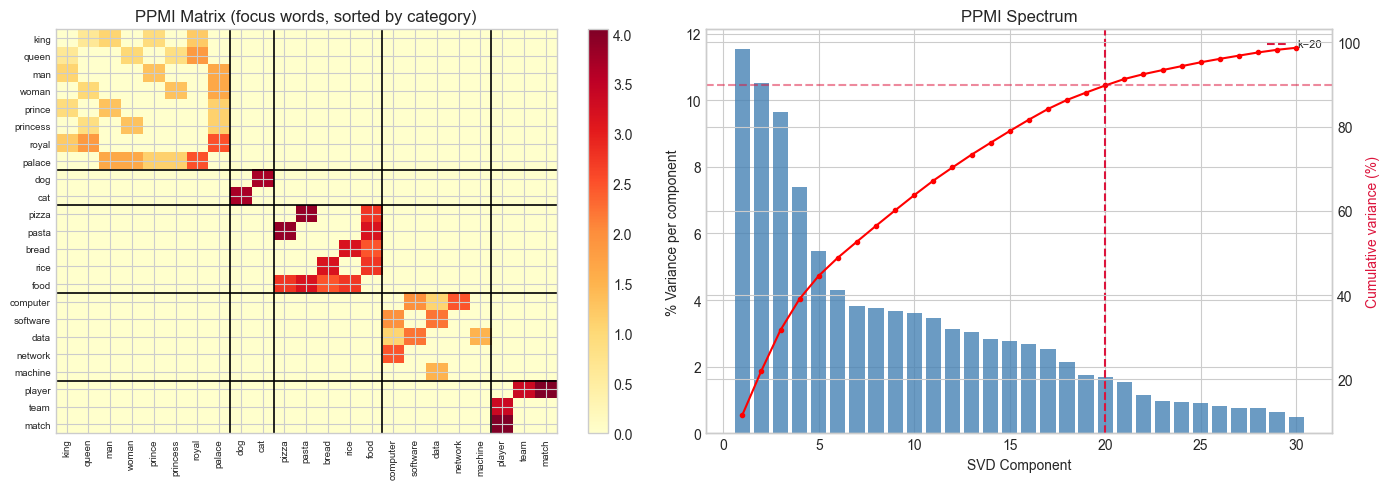

Block structure in PPMI = words that co-occur within semantic categories.


In [5]:
# --- Visualize PPMI structure and SVD spectrum ---
PPMI_focus = PPMI[np.ix_(focus_idx, focus_idx)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PPMI heatmap (focus words sorted by category)
im = axes[0].imshow(PPMI_focus, cmap='YlOrRd', aspect='auto')
axes[0].set_xticks(range(len(focus_order)))
axes[0].set_xticklabels(focus_order, rotation=90, fontsize=7)
axes[0].set_yticks(range(len(focus_order)))
axes[0].set_yticklabels(focus_order, fontsize=7)
axes[0].set_title('PPMI Matrix (focus words, sorted by category)')
plt.colorbar(im, ax=axes[0])

# Draw category boundaries
pos = 0
for _, (words, _) in CATEGORIES.items():
    n = sum(1 for w in words if w in word_to_idx)
    pos += n
    if pos < len(focus_order):
        axes[0].axhline(pos - 0.5, color='black', lw=1.2)
        axes[0].axvline(pos - 0.5, color='black', lw=1.2)

# SVD spectrum
K_SHOW = min(30, len(s_svd))
axes[1].bar(range(1, K_SHOW+1), var_exp[:K_SHOW]*100, color='steelblue', alpha=0.8)
ax2 = axes[1].twinx()
ax2.plot(range(1, K_SHOW+1), cum_var[:K_SHOW]*100, 'r-o', ms=3)
ax2.set_ylabel('Cumulative variance (%)', color='crimson')
ax2.axhline(cum_var[K_EMBED-1]*100, color='crimson', ls='--', alpha=0.5)
axes[1].axvline(K_EMBED, color='crimson', ls='--', label=f'k={K_EMBED}')
axes[1].set_xlabel('SVD Component')
axes[1].set_ylabel('% Variance per component')
axes[1].set_title('PPMI Spectrum')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("Block structure in PPMI = words that co-occur within semantic categories.")

## 3. Stage 2 — Nearest Neighbors and Category Precision

In [6]:
# --- Stage 2: Nearest Neighbor Functions ---

def cosine_nn(query_vec, word_vecs, vocab, exclude_set=None, top_k=6):
    """
    Find top-k nearest neighbors by cosine similarity.
    Returns list of (word, similarity) tuples.
    """
    if exclude_set is None:
        exclude_set = set()

    norms   = np.linalg.norm(word_vecs, axis=1, keepdims=True) + 1e-8
    W_norm  = word_vecs / norms
    q_norm  = query_vec / (np.linalg.norm(query_vec) + 1e-8)
    sims    = W_norm @ q_norm

    for w in exclude_set:
        if w in word_to_idx:
            sims[word_to_idx[w]] = -999

    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(vocab[i], float(sims[i])) for i in top_idx]

def nearest_neighbors(word, word_vecs, vocab, word_to_idx, top_k=6):
    if word not in word_to_idx:
        return []
    q = word_vecs[word_to_idx[word]]
    return cosine_nn(q, word_vecs, vocab, exclude_set={word}, top_k=top_k)

# Spot-check nearest neighbors
print("Nearest neighbors:")
for qw in ['king', 'dog', 'pizza', 'computer', 'player']:
    if qw in word_to_idx:
        nbs = nearest_neighbors(qw, word_vecs, vocab, word_to_idx, top_k=5)
        print(f"  '{qw}': " + ', '.join(f"{w}({s:.2f})" for w, s in nbs))

Nearest neighbors:
  'king': queen(1.00), kingdom(0.57), man(0.39), woman(0.37), palace(0.36)
  'dog': software(0.30), win(0.21), fast(0.18), ran(0.11), network(0.09)
  'pizza': food(0.25), rice(0.25), pasta(0.15), bread(0.10), loyally(0.00)
  'computer': fast(0.71), data(0.39), software(0.30), processed(0.28), network(0.25)
  'player': win(0.29), team(0.18), fast(0.17), ran(0.09), learning(0.02)


In [7]:
# --- Category Precision: quality metric for embeddings ---
# For each focus word, check what fraction of its top-k neighbors are in the same category.
# A perfect embedding concentrates same-category neighbors.

word_to_cat = {}
for cat_name, (words, _) in CATEGORIES.items():
    for w in words:
        word_to_cat[w] = cat_name

def category_precision(word_vecs_k, top_k=4):
    """
    Mean fraction of top-k neighbors that share the same category as the query.
    Only counts neighbors that are also focus words.
    """
    # Build local vocab for this embedding
    hits, total = 0, 0
    for word in word_to_cat:
        if word not in word_to_idx:
            continue
        nbs = nearest_neighbors(word, word_vecs_k, vocab, word_to_idx, top_k=top_k)
        for nb_word, _ in nbs:
            if nb_word in word_to_cat:
                hits  += int(word_to_cat[nb_word] == word_to_cat[word])
                total += 1
    return hits / max(total, 1)

# Sweep over embedding dimension k
# Try changing: K_RANGE_EMBED
K_RANGE_EMBED = [2, 5, 10, 20, 30, 50]
precisions = []
for k_emb in K_RANGE_EMBED:
    wv_k = U_svd[:, :k_emb] * np.sqrt(s_svd[:k_emb])[None, :]
    prec = category_precision(wv_k)
    precisions.append(prec)
    print(f"k={k_emb:3d}:  category precision = {prec:.3f}")

best_k_emb  = K_RANGE_EMBED[int(np.argmax(precisions))]
best_prec   = max(precisions)
print(f"\nBest k={best_k_emb}: {best_prec:.3f}")

k=  2:  category precision = 0.914
k=  5:  category precision = 0.956
k= 10:  category precision = 0.898
k= 20:  category precision = 0.965
k= 30:  category precision = 0.917
k= 50:  category precision = 0.918

Best k=20: 0.965


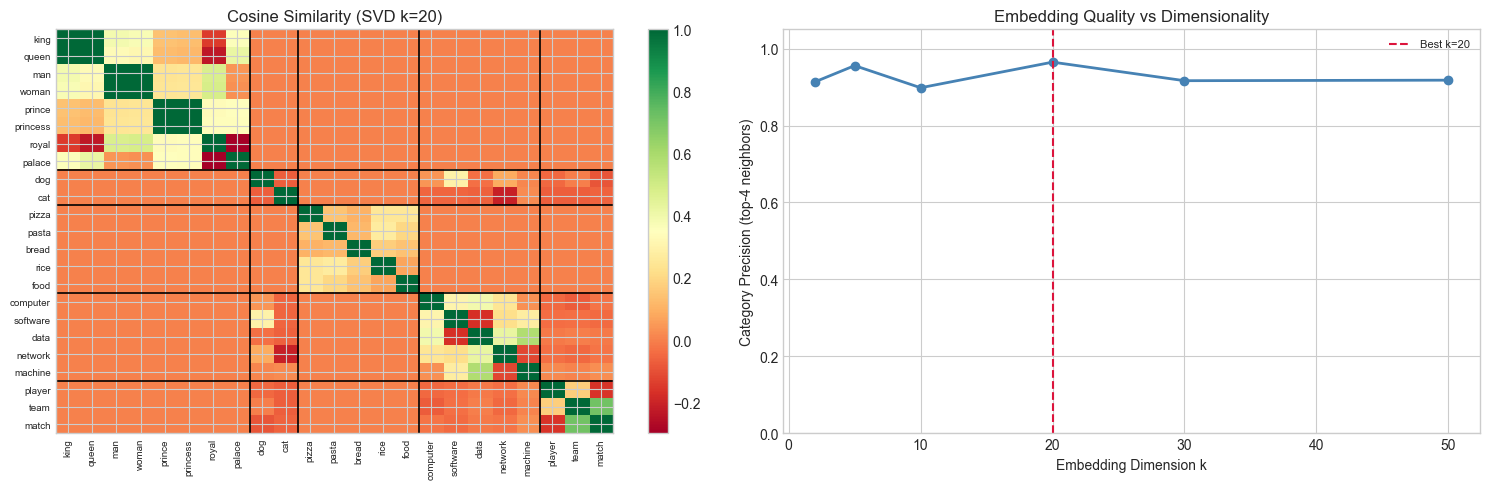

High intra-category, low inter-category similarity = good semantic clustering.


In [8]:
# --- Cosine similarity heatmap for focus words ---
F = len(focus_order)
norms      = np.linalg.norm(focus_vecs, axis=1, keepdims=True) + 1e-8
focus_norm = focus_vecs / norms
sim_matrix = focus_norm @ focus_norm.T

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Similarity matrix
im = axes[0].imshow(sim_matrix, cmap='RdYlGn', vmin=-0.3, vmax=1.0, aspect='auto')
axes[0].set_xticks(range(F))
axes[0].set_xticklabels(focus_order, rotation=90, fontsize=7)
axes[0].set_yticks(range(F))
axes[0].set_yticklabels(focus_order, fontsize=7)
axes[0].set_title(f'Cosine Similarity (SVD k={K_EMBED})')
plt.colorbar(im, ax=axes[0])

pos = 0
for _, (words, _) in CATEGORIES.items():
    n = sum(1 for w in words if w in word_to_idx)
    pos += n
    if pos < F:
        axes[0].axhline(pos-0.5, color='black', lw=1.2)
        axes[0].axvline(pos-0.5, color='black', lw=1.2)

# Category precision vs k
axes[1].plot(K_RANGE_EMBED, precisions, 'o-', ms=6, color='steelblue', lw=2)
axes[1].axvline(best_k_emb, color='crimson', ls='--', label=f'Best k={best_k_emb}')
axes[1].set_xlabel('Embedding Dimension k')
axes[1].set_ylabel('Category Precision (top-4 neighbors)')
axes[1].set_title('Embedding Quality vs Dimensionality')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("High intra-category, low inter-category similarity = good semantic clustering.")

## 4. Stage 3 — Word Arithmetic and Analogy Completion

The analogy *A : B :: C : ?* is solved by finding the word nearest to:
$$\mathbf{q} = \mathbf{v}_A - \mathbf{v}_B + \mathbf{v}_C$$

If the embedding captures the relationship $A \to B$ as a consistent direction in the vector space, then adding that direction to $C$ should land near $D$.

In [9]:
# --- Stage 3: Word Arithmetic ---

def analogy(pos_words, neg_words, word_vecs, vocab, word_to_idx, top_k=5):
    """
    Analogy: find words nearest to sum(pos_vecs) - sum(neg_vecs).
    Excludes all query words from results.
    """
    q = np.zeros(word_vecs.shape[1])
    exclude = set(pos_words) | set(neg_words)
    for w in pos_words:
        if w in word_to_idx:
            q += word_vecs[word_to_idx[w]]
    for w in neg_words:
        if w in word_to_idx:
            q -= word_vecs[word_to_idx[w]]
    return cosine_nn(q, word_vecs, vocab, exclude_set=exclude, top_k=top_k)

print("Word Arithmetic:")
print("=" * 55)

tests = [
    (['king', 'woman'],   ['man'],    "king - man + woman  →  ?"),
    (['queen', 'man'],    ['woman'],  "queen - woman + man →  ?"),
    (['puppy', 'cat'],    ['dog'],    "puppy - dog + cat   →  ?"),  # puppy:dog :: kitten:cat
    (['software', 'food'],['computer'],"software - computer + food → ?"),
    (['player', 'data'],  ['team'],   "player - team + data →  ?"),
]

for pos, neg, desc in tests:
    results = analogy(pos, neg, word_vecs, vocab, word_to_idx, top_k=4)
    top = ', '.join(f"{w}({s:.2f})" for w, s in results)
    print(f"  {desc}")
    print(f"  → {top}")

Word Arithmetic:
  king - man + woman  →  ?
  → queen(0.99), kingdom(0.57), palace(0.35), ruled(0.28)
  queen - woman + man →  ?
  → king(0.99), kingdom(0.53), palace(0.42), served(0.27)
  puppy - dog + cat   →  ?
  → ran(0.25), fast(0.06), algorithms(0.04), match(0.03)
  software - computer + food → ?
  → fresh(0.26), algorithms(0.24), processed(0.21), pizza(0.19)
  player - team + data →  ?
  → machine(0.33), learning(0.33), network(0.24), computer(0.22)


## 5. Stage 4 — 2D Visualization and Geometric Structure

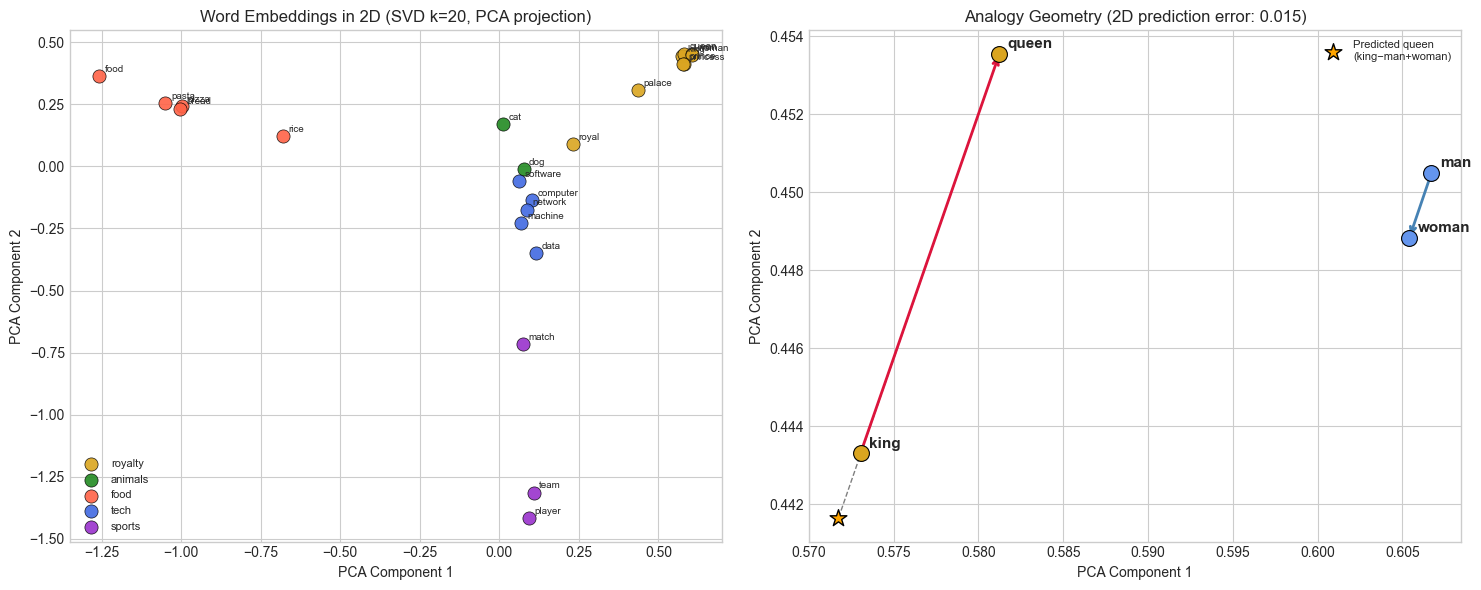

Parallel arrows (king→queen, man→woman) = gender is a consistent direction in embedding space.


In [10]:
# --- Stage 4: PCA projection to 2D ---
# (PCA introduced in ch174)

def pca_2d(X):
    """Project matrix X to 2D via PCA. Returns (n, 2) coordinate array."""
    X_c = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X_c, full_matrices=False)
    return X_c @ Vt[:2].T

coords = pca_2d(focus_vecs)   # (F, 2)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot colored by category
for cat_name, (words, color) in CATEGORIES.items():
    cat_idx = [focus_order.index(w) for w in words if w in focus_order]
    if not cat_idx:
        continue
    xs, ys = coords[cat_idx, 0], coords[cat_idx, 1]
    axes[0].scatter(xs, ys, color=color, s=90, label=cat_name, alpha=0.9,
                   edgecolors='black', lw=0.5, zorder=3)
    for ci in cat_idx:
        axes[0].annotate(focus_order[ci], (coords[ci, 0], coords[ci, 1]),
                        fontsize=7, textcoords='offset points', xytext=(4, 3))

axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].set_title(f'Word Embeddings in 2D (SVD k={K_EMBED}, PCA projection)')
axes[0].legend(fontsize=8, loc='best')

# Analogy geometry
royalty = ['king', 'queen', 'man', 'woman']
r_in   = [w for w in royalty if w in focus_order]
r_coord = {w: coords[focus_order.index(w)] for w in r_in}

axes[1].set_title('Analogy Geometry: king − man + woman ≈ queen')

if all(w in r_coord for w in royalty):
    k_c, q_c = r_coord['king'],  r_coord['queen']
    m_c, w_c = r_coord['man'],   r_coord['woman']

    for w, c in r_coord.items():
        color = 'goldenrod' if w in ['king','queen'] else 'cornflowerblue'
        axes[1].scatter(*c, s=130, color=color, edgecolors='black', lw=0.8, zorder=4)
        axes[1].annotate(w, c, fontsize=11, fontweight='bold',
                        textcoords='offset points', xytext=(6, 4))

    # Gender direction arrow: king→queen, man→woman
    for start, end, col, lbl in [(k_c, q_c, 'crimson', 'king→queen'),
                                  (m_c, w_c, 'steelblue', 'man→woman')]:
        axes[1].annotate('', xy=end, xytext=start,
                        arrowprops=dict(arrowstyle='->', color=col, lw=2))

    # Predicted queen = king - man + woman
    pred = k_c - m_c + w_c
    axes[1].scatter(*pred, s=160, color='orange', marker='*', zorder=5,
                   edgecolors='black', label='Predicted queen\n(king−man+woman)')
    axes[1].plot([q_c[0], pred[0]], [q_c[1], pred[1]], 'k--', lw=1, alpha=0.5)

    err = np.linalg.norm(pred - q_c)
    axes[1].legend(fontsize=8)
    axes[1].set_title(f'Analogy Geometry (2D prediction error: {err:.3f})')

axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()
print("Parallel arrows (king→queen, man→woman) = gender is a consistent direction in embedding space.")

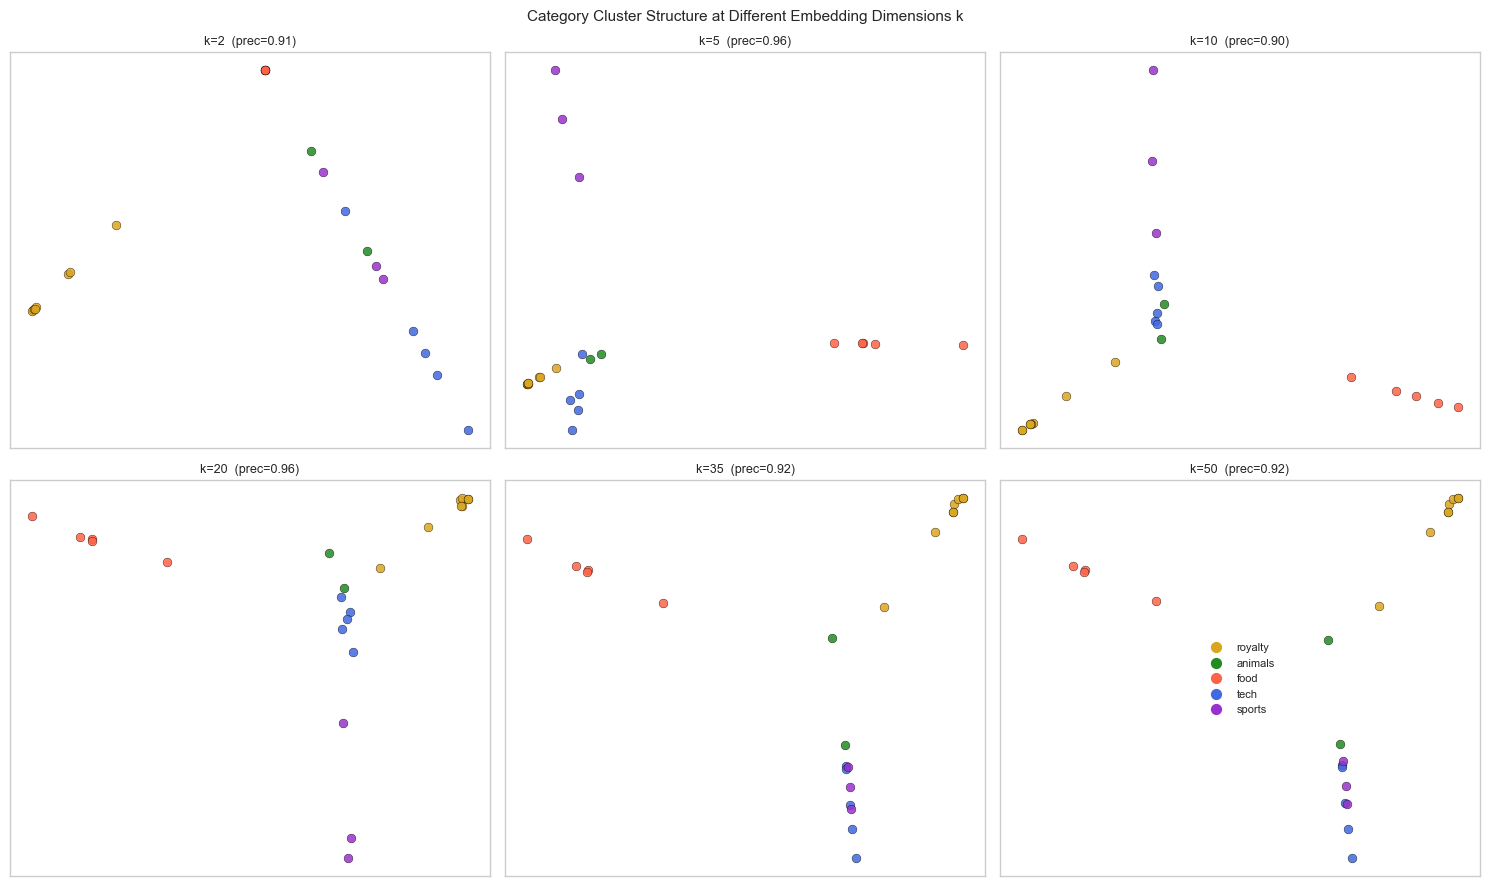

Optimal k balances expressivity (enough dimensions to separate categories)
and noise (fewer dimensions = less overfitting to corpus artifacts).


In [11]:
# --- Experiment: How does k affect cluster separation? ---
# Hypothesis: too few dimensions loses category structure; too many introduces noise.
# Try changing: K_RANGE_EMBED, WINDOW_SIZE, MIN_FREQ at the top

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

K_VIZ = [2, 5, 10, 20, 35, 50]
for ax_i, k_emb in enumerate(K_VIZ):
    wv_k   = U_svd[:, :k_emb] * np.sqrt(s_svd[:k_emb])[None, :]
    fv_k   = wv_k[focus_idx]
    coords_k = pca_2d(fv_k)
    prec_k = category_precision(wv_k)

    for cat_name, (words, color) in CATEGORIES.items():
        cat_idx = [focus_order.index(w) for w in words if w in focus_order]
        if not cat_idx:
            continue
        axes[ax_i].scatter(coords_k[cat_idx, 0], coords_k[cat_idx, 1],
                          color=color, s=40, alpha=0.85, edgecolors='black', lw=0.3)

    axes[ax_i].set_title(f'k={k_emb}  (prec={prec_k:.2f})', fontsize=9)
    axes[ax_i].set_xticks([]); axes[ax_i].set_yticks([])

# Legend in last subplot (already used, just add manually)
for cat_name, (words, color) in CATEGORIES.items():
    axes[-1].scatter([], [], color=color, s=50, label=cat_name)
axes[-1].legend(fontsize=8, loc='center')
axes[-1].set_xticks([]); axes[-1].set_yticks([])

fig.suptitle('Category Cluster Structure at Different Embedding Dimensions k', fontsize=11)
plt.tight_layout()
plt.show()
print("Optimal k balances expressivity (enough dimensions to separate categories)")
print("and noise (fewer dimensions = less overfitting to corpus artifacts).")

## 6. Results & Reflection

### What Was Built

A complete word embedding pipeline: corpus → tokenization → co-occurrence matrix → PPMI weighting → SVD → word vectors → nearest-neighbor retrieval → analogy completion → 2D visualization.

### What Math Made It Possible

| Step | Math | Chapter |
|---|---|---|
| Co-occurrence matrix | Count-based statistics | — |
| PPMI weighting | $\max(0, \log P(w,c)/P(w)P(c))$ | probability (anticipates ch241) |
| SVD factorization | $X = U\Sigma V^\top$ | ch173 |
| Word vectors | $U_k \Sigma_k^{1/2}$ — left singular vectors scaled by sqrt(eigenvalues) | ch173, ch174 |
| Nearest neighbor | Cosine similarity: $\mathbf{u}^\top \mathbf{v} / (\|\mathbf{u}\|\|\mathbf{v}\|)$ | ch143 |
| Analogy | Vector arithmetic: $\mathbf{v}_A - \mathbf{v}_B + \mathbf{v}_C$ | ch121–130 |
| 2D projection | PCA via SVD *(ch174)* | ch174, ch175 |

### Why SVD Recovers Semantic Structure

The PPMI matrix encodes which words appear in each other's context more than chance. SVD finds the dominant axes of this co-occurrence structure — directions that explain the most variance in how words relate to each other. These axes end up aligned with latent topics or semantic categories, because words in the same category tend to appear in similar contexts.

The analogy property (*king − man + woman ≈ queen*) holds when the gender-related co-occurrence pattern is consistent: "king" and "man" share contexts that "queen" and "woman" share too. The difference vector encodes that consistent co-occurrence offset.

### Extension Challenges

**Challenge 1 — Window Size Sensitivity.** Vary `WINDOW_SIZE` from 1 to 10 and track category precision. Small windows capture syntactic relationships; large windows capture semantic/topical ones. Plot precision vs window size.

**Challenge 2 — GloVe-Style Weighting.** The GloVe model weights co-occurrences by $f(c_{ij}) = \min(1, (c_{ij}/c_{\max})^\alpha)$ before factorization. Implement this weighting (replace PPMI), fit SVD, and compare category precision to the PPMI approach.

**Challenge 3 — Intrinsic vs Extrinsic Evaluation.** Category precision (used here) is an *intrinsic* metric — it measures embedding geometry. An *extrinsic* metric evaluates on a downstream task. Implement a simple sentiment classifier: assign each sentence a "valence" vector by averaging its word vectors, then train a linear separator. Measure accuracy vs. embedding dimension k.

---

## 7. Summary & Connections

- Word embeddings are low-rank factorizations of the co-occurrence (PPMI) matrix; SVD finds the optimal factorization in Frobenius norm *(ch173, Eckart-Young)*.
- Cosine similarity in embedding space captures semantic relatedness; nearest-neighbor search is the core operation of retrieval *(ch143, ch129)*.
- Word arithmetic (*king − man + woman ≈ queen*) reflects that semantic relationships are approximately encoded as consistent vector offsets — a linear structure *(ch121–130)*.
- Embedding quality peaks at an intermediate dimension $k$: too small loses distinctions, too large fits corpus noise *(ch175)*.

**Forward:** ch191 (Project: Graph Embedding) extends these ideas to node embeddings in graphs — the same SVD machinery applied to adjacency or Laplacian matrices. In Part IX, ch279 (Neural Network Math Review) connects SVD-based embeddings to learned embeddings (Word2Vec, GloVe, transformer attention), where the same cosine similarity and nearest-neighbor operations appear but with gradients replacing closed-form SVD.

**Backward:** The factorization $X \approx U_k \Sigma_k V_k^\top$ is the same operation used in ch180 (image compression) and ch187 (face recognition). Only the interpretation of the matrix changes — pixels, face data, or word co-occurrences — the linear algebra is identical.